# Day26_logistic regression
07-04-25

# Step 1 - Define the problem

# Step 2 - Collect and Prepare Data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.graphics.regressionplots as influence_plot

In [2]:
data=pd.read_csv('claimants.csv')
data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


## step 2.1 Examine the data

In [3]:
data.shape

(1340, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   ATTORNEY  1340 non-null   int64  
 2   CLMSEX    1328 non-null   float64
 3   CLMINSUR  1299 non-null   float64
 4   SEATBELT  1292 non-null   float64
 5   CLMAGE    1151 non-null   float64
 6   LOSS      1340 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


- There are multiple null values in multiple columns

In [5]:
data.columns

Index(['CASENUM', 'ATTORNEY', 'CLMSEX', 'CLMINSUR', 'SEATBELT', 'CLMAGE',
       'LOSS'],
      dtype='object')

In [6]:
data.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


In [7]:
data.isnull().sum() # it will provide null calues in each column


CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [8]:
# compute the null values
# CLMSEX_mode=data['CLMSEX'].mode()
CLMSEX_mode=data['CLMSEX'].mode()[0]
CLMSEX_mode

np.float64(1.0)

In [9]:
# CLMINSUR     
data['CLMINSUR'].value_counts()

CLMINSUR
1.0    1179
0.0     120
Name: count, dtype: int64

In [10]:
CLMINSUR_mode=data['CLMINSUR'].mode()[0]
CLMINSUR_mode

np.float64(1.0)

In [11]:
# SEATBELT
print(data['SEATBELT'].value_counts())
SEATBELT_mode=data['SEATBELT'].mode()[0]
SEATBELT_mode

SEATBELT
0.0    1270
1.0      22
Name: count, dtype: int64


np.float64(0.0)

In [12]:
# CLMAGE
CLMAGE_mean=data['CLMAGE'].mean()
CLMAGE_mean


np.float64(28.414422241529106)

In [13]:
data.fillna({'CLMSEX':CLMSEX_mode,'CLMINSUR':CLMINSUR_mode,'SEATBELT':SEATBELT_mode,'CLMAGE':CLMAGE_mean},inplace=True)

In [14]:
data.isnull().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [15]:
data.drop('CASENUM',axis=1,inplace=True)


In [16]:
data

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.000000,34.940
1,1,1.0,0.0,0.0,18.000000,0.891
2,1,0.0,1.0,0.0,5.000000,0.330
3,0,0.0,1.0,1.0,31.000000,0.037
4,1,0.0,1.0,0.0,30.000000,0.038
...,...,...,...,...,...,...
1335,1,0.0,1.0,0.0,28.414422,0.576
1336,0,1.0,1.0,0.0,46.000000,3.705
1337,1,1.0,1.0,0.0,39.000000,0.099
1338,0,1.0,0.0,0.0,8.000000,3.177


In [17]:
data['ATTORNEY'].value_counts()

ATTORNEY
0    685
1    655
Name: count, dtype: int64

In [18]:
data['CLMAGE'].value_counts()

CLMAGE
28.414422    189
10.000000     61
40.000000     55
6.000000      46
30.000000     45
            ... 
95.000000      1
84.000000      1
88.000000      1
74.000000      1
86.000000      1
Name: count, Length: 69, dtype: int64

<Axes: xlabel='ATTORNEY', ylabel='CLMAGE'>

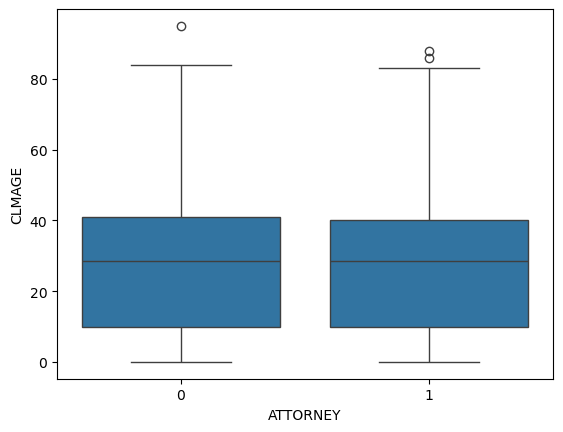

In [19]:
sns.boxplot(x='ATTORNEY',y='CLMAGE',data=data)

### Step 2.1.1 - check x can be used to predict Y 

#### Step 2.1.1.1 Scatter plot

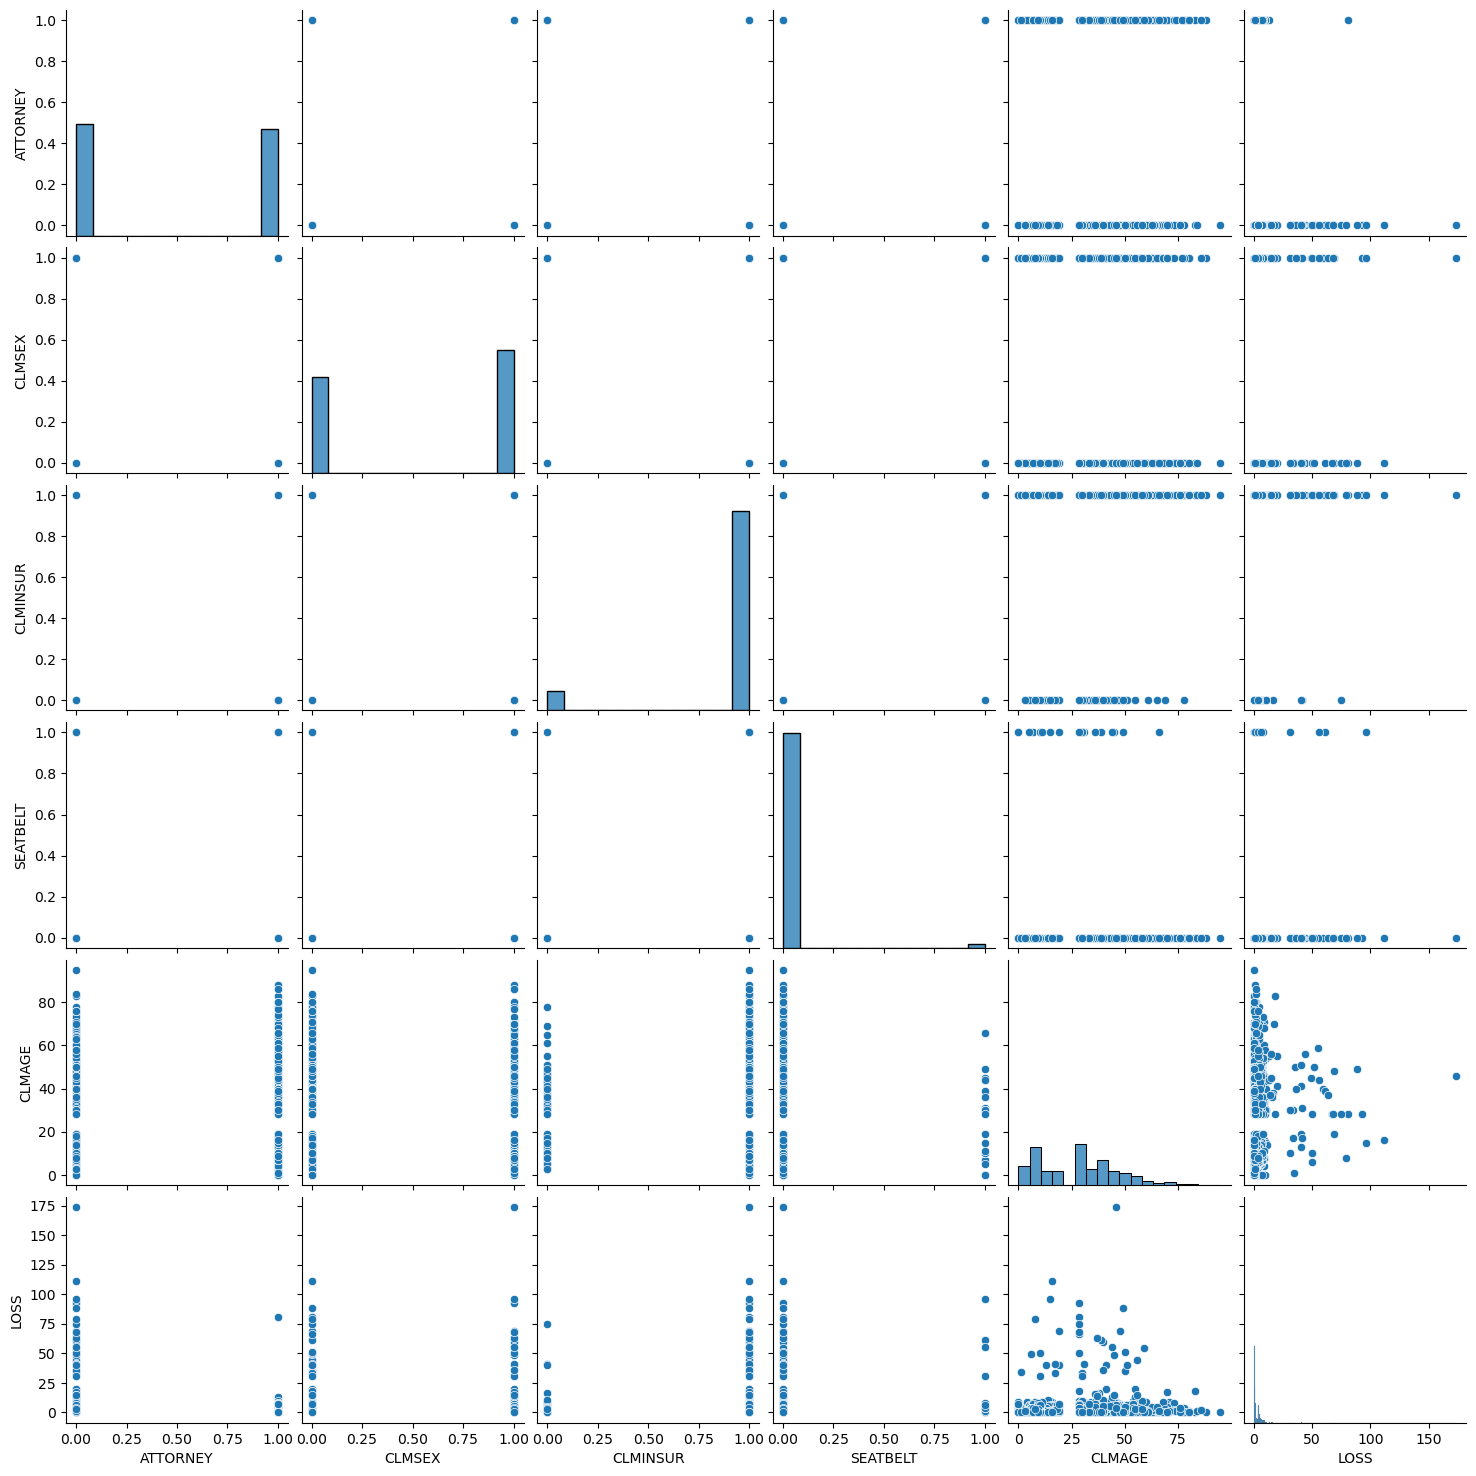

In [20]:
sns.pairplot(data)
plt.show()

#### 2.1.1.2 Correlation matrix

In [21]:
corr=data.corr()
print(corr)
print(type(corr))

          ATTORNEY    CLMSEX  CLMINSUR  SEATBELT    CLMAGE      LOSS
ATTORNEY  1.000000  0.076564  0.076631 -0.055848  0.009886 -0.219715
CLMSEX    0.076564  1.000000  0.065976 -0.016327 -0.022444 -0.028412
CLMINSUR  0.076631  0.065976  1.000000  0.019953  0.044706  0.004641
SEATBELT -0.055848 -0.016327  0.019953  1.000000 -0.025379  0.111879
CLMAGE    0.009886 -0.022444  0.044706 -0.025379  1.000000  0.057641
LOSS     -0.219715 -0.028412  0.004641  0.111879  0.057641  1.000000
<class 'pandas.core.frame.DataFrame'>


<Axes: >

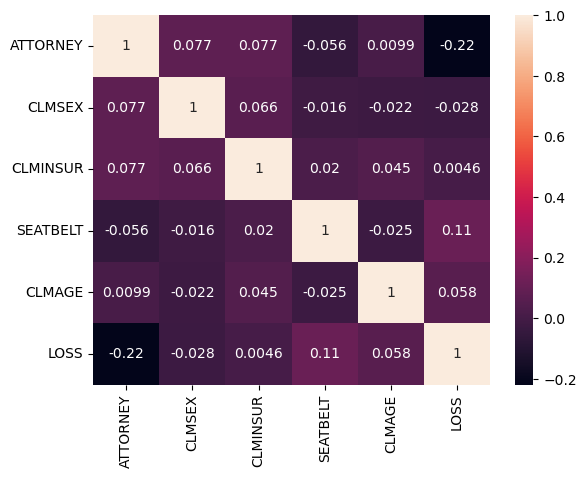

In [22]:
sns.heatmap(corr,annot=True)

# Step 3 - Split the Data

## Step 3.1 - find out independent and dependent variable

In [23]:
- dpendent varaible - Y - attorney
- independent varaible x - remaining columns

SyntaxError: invalid syntax (307813693.py, line 1)

In [24]:
x=data.iloc[:,1:]
y=data.iloc[:,0]

In [25]:
x.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [26]:
y.head()

0    0
1    1
2    1
3    0
4    1
Name: ATTORNEY, dtype: int64

## Step 3.2 split the data into X-train and Y-train

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((1072, 5), (1072,), (268, 5), (268,))

# Step 4 - Choose the Algorithm and Build the model

- As target column is catogorical, so it is a classification
- Logistic regression

In [28]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

# Step 5 -Train the Model

In [29]:
model.fit(x_train,y_train)

LogisticRegression()

# Step 6 - Evaluate the Model

## Step 6.1 - predict the values for training data(x_train) - yhat_train

In [30]:
yhat_train=model.predict(x_train)
yhat_train

array([0, 0, 1, ..., 1, 1, 1])

In [31]:
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score,roc_curve

In [32]:
cm = confusion_matrix(y_train,yhat_train)
cm

array([[352, 205],
       [113, 402]])

In [33]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.76      0.63      0.69       557
           1       0.66      0.78      0.72       515

    accuracy                           0.70      1072
   macro avg       0.71      0.71      0.70      1072
weighted avg       0.71      0.70      0.70      1072



In [35]:
def plot_roc(y,yhat):
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve')
    plt.xlabel('False positive Rate(FPR)')
    plt.ylabel('True positive Rate(TPR)')

    fpr,tpr,thresh=roc_curve(y,yhat)  # by default threshold will 50%
    auc=roc_auc_score(y,yhat)
    auc
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],'o--')
    plt.show()

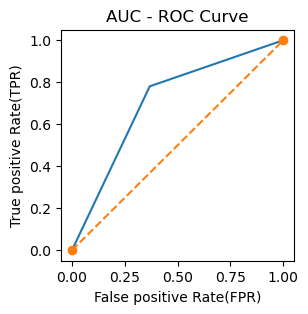

In [36]:
plot_roc(y_train,yhat_train)

## Step 6.3 - Predict the output  Check the measure for x_test data and evaluate the model

### Step 6.3.1 model with default 50% threshold

In [37]:
yhat_test=model.predict(x_test)
yhat_test

array([0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1])

In [38]:
cm_Test = confusion_matrix(y_test,yhat_test)
cm_Test 

array([[ 85,  43],
       [ 27, 113]])

In [42]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.76      0.66      0.71       128
           1       0.72      0.81      0.76       140

    accuracy                           0.74       268
   macro avg       0.74      0.74      0.74       268
weighted avg       0.74      0.74      0.74       268



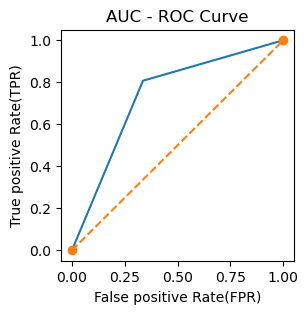

In [43]:
plot_roc(y_test,yhat_test)

# Day27
08-apr-25

In [44]:
# predicts the output in probability - it will give us flexibility to show the output based on our requirement
# Rather than using model.predict(x_test) to predict yhat better we use predict_proba
# this will return 2 outputs for one input.1) positive probability 2) negative probability. The sum of both should be 1.
model.predict_proba(x_test)


array([[7.87145035e-01, 2.12854965e-01],
       [8.77960892e-01, 1.22039108e-01],
       [2.98778497e-01, 7.01221503e-01],
       [3.84273994e-01, 6.15726006e-01],
       [8.30528443e-01, 1.69471557e-01],
       [6.43712818e-01, 3.56287182e-01],
       [3.98895524e-01, 6.01104476e-01],
       [4.53283955e-01, 5.46716045e-01],
       [4.41932117e-01, 5.58067883e-01],
       [8.78580031e-01, 1.21419969e-01],
       [3.42422661e-01, 6.57577339e-01],
       [3.19178286e-01, 6.80821714e-01],
       [4.09705349e-01, 5.90294651e-01],
       [4.44536372e-01, 5.55463628e-01],
       [3.22663277e-01, 6.77336723e-01],
       [7.37554420e-01, 2.62445580e-01],
       [3.33741636e-01, 6.66258364e-01],
       [2.74492263e-01, 7.25507737e-01],
       [3.44046758e-01, 6.55953242e-01],
       [9.12972434e-01, 8.70275656e-02],
       [1.00000000e+00, 1.25764722e-12],
       [7.01147518e-01, 2.98852482e-01],
       [7.59171526e-01, 2.40828474e-01],
       [5.03831083e-01, 4.96168917e-01],
       [8.010205

In [45]:
def pk_prob(p_prob):
    if p_prob>0.6:
        return 1
    else:
        return 0    

In [46]:
pk_prob(0.050)

0

In [47]:
#model.predict_proba(x_test)

### Step 6.3.1 model with default 60% threshold

In [48]:
y_hat_60=pd.Series(model.predict_proba(x_test)[:,1]).apply(pk_prob)
y_hat_60.head(20)

0     0
1     0
2     1
3     1
4     0
5     0
6     1
7     0
8     0
9     0
10    1
11    1
12    0
13    0
14    1
15    0
16    1
17    1
18    1
19    0
dtype: int64

In [49]:
y_hat_60.shape

(268,)

In [50]:
cm_Test = confusion_matrix(y_test,y_hat_60)
cm_Test 

array([[99, 29],
       [47, 93]])

In [51]:
print(classification_report(y_test,y_hat_60))

              precision    recall  f1-score   support

           0       0.68      0.77      0.72       128
           1       0.76      0.66      0.71       140

    accuracy                           0.72       268
   macro avg       0.72      0.72      0.72       268
weighted avg       0.72      0.72      0.72       268



### Step 6.3.1 model with default 90% threshold

In [52]:
def pk_prob2(p_prob):
    if p_prob>0.90:
        return 1
    else:
        return 0 

In [53]:
y_hat_90=pd.Series(model.predict_proba(x_test)[:,1]).apply(pk_prob2)
y_hat_90.head(20)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

In [54]:
cm_Test = confusion_matrix(y_test,y_hat_90)
cm_Test 

array([[128,   0],
       [140,   0]])

In [55]:
print(classification_report(y_test,y_hat_90))

              precision    recall  f1-score   support

           0       0.48      1.00      0.65       128
           1       0.00      0.00      0.00       140

    accuracy                           0.48       268
   macro avg       0.24      0.50      0.32       268
weighted avg       0.23      0.48      0.31       268



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 6.3.1 model with default 30% threshold

In [56]:
def pk_prob3(p_prob):
    if p_prob>0.30:
        return 1
    else:
        return 0 

In [57]:
y_hat_30=pd.Series(model.predict_proba(x_test)[:,1]).apply(pk_prob3)
y_hat_30.head(20)

0     0
1     0
2     1
3     1
4     0
5     1
6     1
7     1
8     1
9     0
10    1
11    1
12    1
13    1
14    1
15    0
16    1
17    1
18    1
19    0
dtype: int64

In [58]:
cm_Test = confusion_matrix(y_test,y_hat_30)
cm_Test 

array([[ 43,  85],
       [ 16, 124]])

In [59]:
print(classification_report(y_test,y_hat_30))

              precision    recall  f1-score   support

           0       0.73      0.34      0.46       128
           1       0.59      0.89      0.71       140

    accuracy                           0.62       268
   macro avg       0.66      0.61      0.59       268
weighted avg       0.66      0.62      0.59       268

